# Phase And Amplitude Visualization

Purpose: inspect CSI phase and amplitude across streams, time, and subcarriers with a deterministic synthetic capture.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The notebook is self-contained and does not require hardware recordings.

Fixture / simulated source: `make_phase_amplitude_fixture` creates a 160-frame, 3-stream, 64-subcarrier CSI capture with smooth static channel structure, breathing-like low-rate phase movement, a localized motion burst, and tiny seeded noise.

Plots: stream-0 amplitude heatmap, stream-0 wrapped phase heatmap, center-subcarrier unwrapped phase by stream, and center-band amplitude over time.


In [1]:
import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError('Install the research extra with `uv sync --extra research` to run this notebook.') from exc


def make_phase_amplitude_fixture(
    n_frames=160,
    n_streams=3,
    n_subcarriers=64,
    sample_rate_hz=20.0,
    seed=404,
):
    rng = np.random.default_rng(seed)
    time_s = np.arange(n_frames, dtype=float) / sample_rate_hz
    streams = np.arange(n_streams, dtype=float)
    subcarriers = np.arange(n_subcarriers, dtype=float)

    center = 39.0
    body_band = np.exp(-0.5 * ((subcarriers - center) / 5.5) ** 2)
    static_amplitude = 1.0 + 0.07 * np.cos((subcarriers - 20.0) / 8.0)
    stream_gain = (1.0 + 0.045 * streams)[None, :, None]

    breathing = np.sin(2.0 * np.pi * 0.28 * time_s)[:, None, None]
    motion_burst = np.exp(-0.5 * ((time_s - 4.2) / 0.55) ** 2)[:, None, None]
    amplitude = stream_gain * (
        static_amplitude[None, None, :]
        + 0.08 * breathing * body_band[None, None, :]
        + 0.18 * motion_burst * body_band[None, None, :]
    )
    amplitude = amplitude + rng.normal(0.0, 0.008, size=amplitude.shape)

    static_phase = 0.05 * subcarriers[None, None, :] + 0.38 * streams[None, :, None]
    slow_drift = 0.035 * time_s[:, None, None]
    body_phase = 0.16 * np.sin(
        2.0 * np.pi * 0.28 * time_s[:, None, None] + 0.25 * streams[None, :, None]
    ) * body_band[None, None, :]
    wrapped_phase = np.angle(np.exp(1j * (static_phase + slow_drift + body_phase)))

    csi = amplitude * np.exp(1j * wrapped_phase)
    return {
        'csi': csi,
        'time_s': time_s,
        'subcarriers': subcarriers,
        'sample_rate_hz': sample_rate_hz,
        'body_band': body_band,
        'motion_window_s': (3.4, 5.0),
    }


fixture = make_phase_amplitude_fixture()
csi = fixture['csi']
amplitude = np.abs(csi)
wrapped_phase = np.angle(csi)
unwrapped_phase = np.unwrap(wrapped_phase, axis=0)
relative_phase = unwrapped_phase - unwrapped_phase[0:1]

print(f"CSI shape [time, stream, subcarrier]: {csi.shape}")
print(f"Mean amplitude: {amplitude.mean():.3f}")
print(f"Wrapped phase range: {wrapped_phase.min():.2f} to {wrapped_phase.max():.2f} rad")


CSI shape [time, stream, subcarrier]: (160, 3, 64)
Mean amplitude: 1.051
Wrapped phase range: -3.14 to 3.14 rad


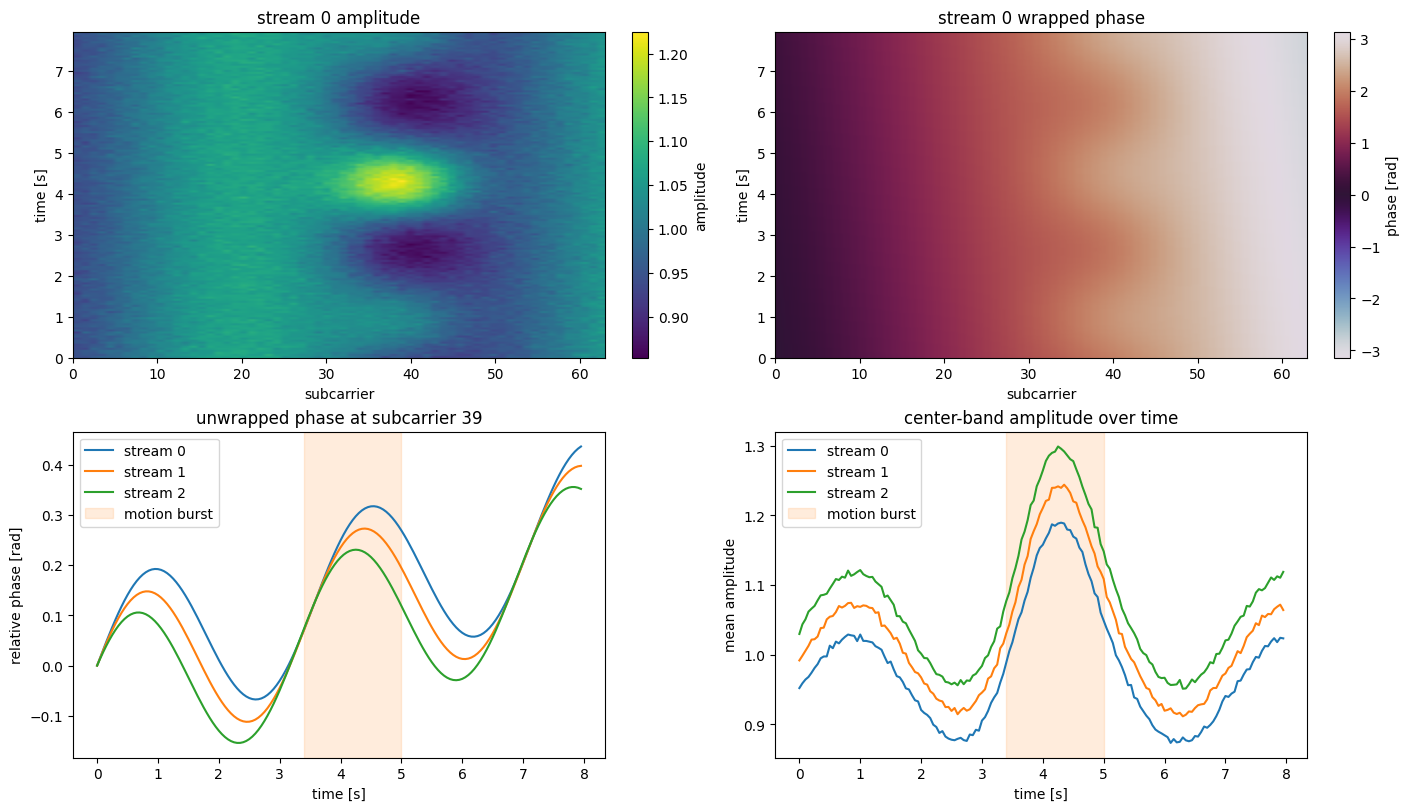

In [2]:
time_s = fixture['time_s']
subcarriers = fixture['subcarriers']
center_index = int(np.argmax(fixture['body_band']))
extent = [subcarriers[0], subcarriers[-1], time_s[0], time_s[-1]]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

amp_image = axes[0, 0].imshow(
    amplitude[:, 0, :],
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='viridis',
)
axes[0, 0].set_title('stream 0 amplitude')
axes[0, 0].set_xlabel('subcarrier')
axes[0, 0].set_ylabel('time [s]')
fig.colorbar(amp_image, ax=axes[0, 0], label='amplitude')

phase_image = axes[0, 1].imshow(
    wrapped_phase[:, 0, :],
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='twilight',
    vmin=-np.pi,
    vmax=np.pi,
)
axes[0, 1].set_title('stream 0 wrapped phase')
axes[0, 1].set_xlabel('subcarrier')
axes[0, 1].set_ylabel('time [s]')
fig.colorbar(phase_image, ax=axes[0, 1], label='phase [rad]')

for stream_index in range(csi.shape[1]):
    axes[1, 0].plot(
        time_s,
        relative_phase[:, stream_index, center_index],
        label=f'stream {stream_index}',
    )
axes[1, 0].axvspan(*fixture['motion_window_s'], color='tab:orange', alpha=0.14, label='motion burst')
axes[1, 0].set_title(f'unwrapped phase at subcarrier {center_index}')
axes[1, 0].set_xlabel('time [s]')
axes[1, 0].set_ylabel('relative phase [rad]')
axes[1, 0].legend(loc='upper left')

center_band = slice(center_index - 3, center_index + 4)
for stream_index in range(csi.shape[1]):
    axes[1, 1].plot(
        time_s,
        amplitude[:, stream_index, center_band].mean(axis=1),
        label=f'stream {stream_index}',
    )
axes[1, 1].axvspan(*fixture['motion_window_s'], color='tab:orange', alpha=0.14, label='motion burst')
axes[1, 1].set_title('center-band amplitude over time')
axes[1, 1].set_xlabel('time [s]')
axes[1, 1].set_ylabel('mean amplitude')
axes[1, 1].legend(loc='upper left')

plt.show()


Expected interpretation: the amplitude heatmap should show a stable static channel plus a localized high-energy band near the synthetic body subcarriers. Wrapped phase should stay bounded in `[-pi, pi]`, while the unwrapped center-subcarrier trace should reveal smooth low-rate phase motion and a visible drift shared across streams.

Limitations: this is a deterministic visual fixture, not a calibrated RF capture. It does not model packet loss, CFO/SFO correction, antenna coupling, AGC changes, multi-person interference, ESP32 quantization, or phase-sanitizer parity with the Rust implementation. Use it as a shape and plotting smoke test before replacing the fixture with recorded CSI.
